In [1]:
import digitalhub as dh
import pandas as pd
import requests
import os
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT = "test-otp-v2"
project = dh.get_or_create_project(PROJECT)

zoi: str = "allBologna"  ## Choose between "allBologna" and "restrictedAv"
method: str = "simplified" ## Choose between "simplified" and "extended"
version: str = "20250926"

In [2]:
df_car_trans_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_TRANSIT_v{version}")
df_car_trans = df_car_trans_di.as_df()

df_car_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_v{version}")
df_car = df_car_di.as_df()

df_car_park_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_v{version}")
df_car_park = df_car_park_di.as_df()

df_trans_di = project.get_dataitem(f"otp_results_{method}_{zoi}_TRANSIT_v{version}")
df_trans = df_trans_di.as_df()

print(df_car.columns)

Index(['row_index', 'origin_lat', 'origin_lon', 'from', 'dest_lat', 'dest_lon',
       'to', 'origin_lat_tmp', 'origin_lon_tmp', 'dest_lat_tmp',
       'dest_lon_tmp', 'n_iter', 'status', 'duration_seconds',
       'walk_time_seconds', 'number_of_legs', 'transport_modes',
       'transport_mode_sequences', 'transport_durations',
       'transport_percentages', 'number_of_transit_transfers', 'start_time',
       'end_time'],
      dtype='object')


# CAR E CAR_PARK

In [3]:
# Confronto i df in car con e senza park
df_compare = pd.merge(
    df_car_park, 
    df_car, 
    on=['row_index', 'origin_lat', 'origin_lon', 'from', 'dest_lat', 'dest_lon','to'], 
    how='outer',
    suffixes=["_carPark","_car"])

print("N. NAs in car:", int(df_compare["duration_seconds_car"].isna().sum()))
print("N. NAs in carPark:", int(df_compare["duration_seconds_carPark"].isna().sum()))

print("N. success in car:", sum(df_compare["status_car"]=="success"))
print("N. success in carPark:", sum(df_compare["status_carPark"]=="success"))

df_compare.head()

N. NAs in car: 0
N. NAs in carPark: 0
N. success in car: 152
N. success in carPark: 152


,row_index,origin_lat,origin_lon,from,dest_lat,dest_lon,to,origin_lat_tmp_carPark,origin_lon_tmp_carPark,dest_lat_tmp_carPark,...,duration_seconds_car,walk_time_seconds_car,number_of_legs_car,transport_modes_car,transport_mode_sequences_car,transport_durations_car,transport_percentages_car,number_of_transit_transfers_car,start_time_car,end_time_car
0,0,44.109145,10.939834,8037029,44.497006,11.344162,0,44.109145,10.939834,44.497006,...,5051,0,1,[CAR],[],[5051.0],[100.0],0,2025-06-10T07:00:00+02:00,2025-06-10T08:24:11+02:00
1,1,44.149540,10.931946,8037049,44.497006,11.344162,0,44.149540,10.931946,44.497006,...,4380,0,1,[CAR],[],[4380.0],[100.0],0,2025-06-10T07:00:00+02:00,2025-06-10T08:13:00+02:00
2,2,44.150671,11.183166,8037022,44.497006,11.344162,0,44.150671,11.183166,44.497006,...,2351,0,1,[CAR],[],[2351.0],[100.0],0,2025-06-10T07:00:00+02:00,2025-06-10T07:39:11+02:00
3,3,44.152876,11.095953,8037010,44.497006,11.344162,0,44.152876,11.095953,44.497006,...,3357,0,1,[CAR],[],[3357.0],[100.0],0,2025-06-10T07:00:00+02:00,2025-06-10T07:55:57+02:00
4,4,44.159536,11.022521,8037015,44.497006,11.344162,0,44.159536,11.022521,44.497006,...,4075,0,1,[CAR],[],[4075.0],[100.0],0,2025-06-10T07:00:00+02:00,2025-06-10T08:07:55+02:00


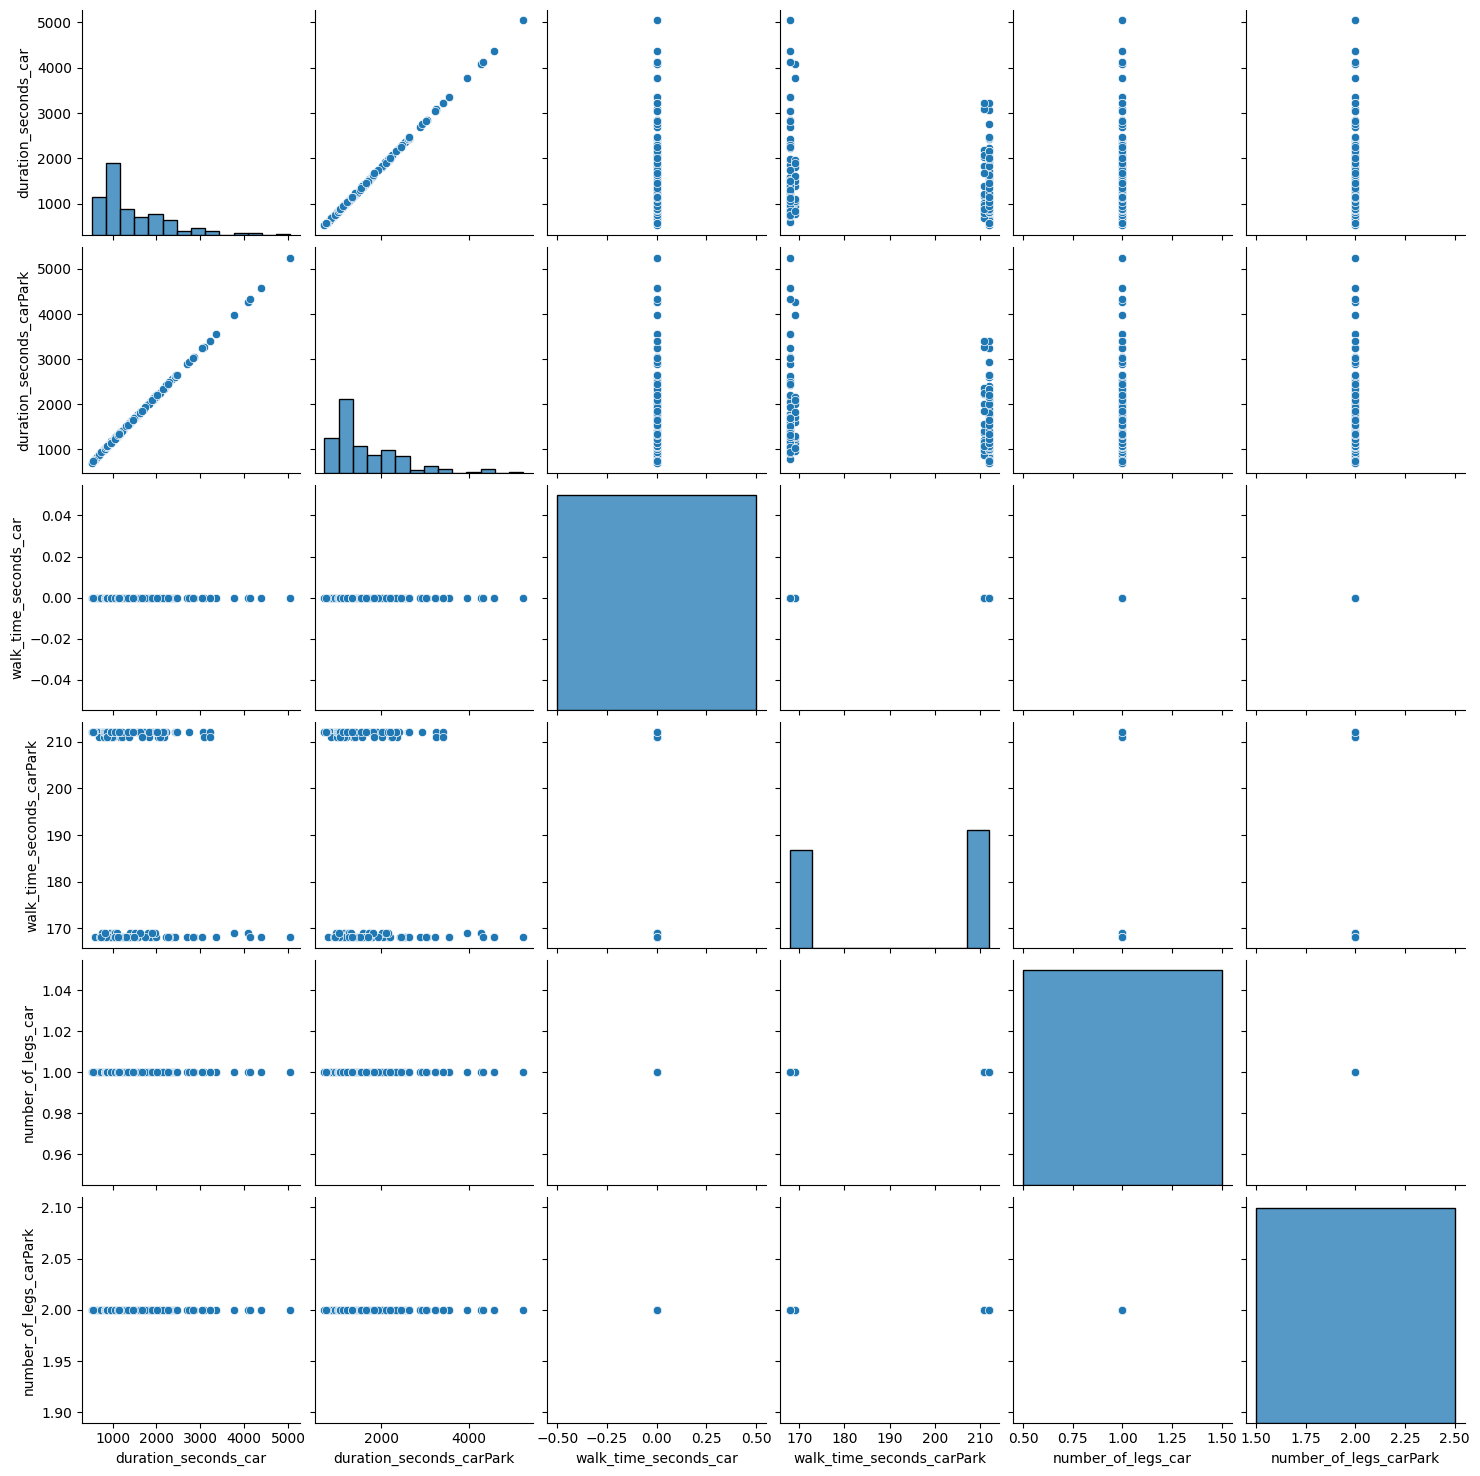

In [4]:
sns.pairplot(
    data=df_compare[["duration_seconds_car", "duration_seconds_carPark",
                        "walk_time_seconds_car", "walk_time_seconds_carPark",
                        "number_of_legs_car", "number_of_legs_carPark"]],
    diag_kind="hist"
)
    

In [5]:
print("Min diff:", min(df_compare["duration_seconds_car"] - df_compare["duration_seconds_carPark"]))
print("Max diff:", max(df_compare["duration_seconds_car"] - df_compare["duration_seconds_carPark"]))
print("Mean diff:", sum(df_compare["duration_seconds_car"] - df_compare["duration_seconds_carPark"])/df_compare.shape[0])

Min diff: -201
Max diff: -180
Mean diff: -189.28947368421052


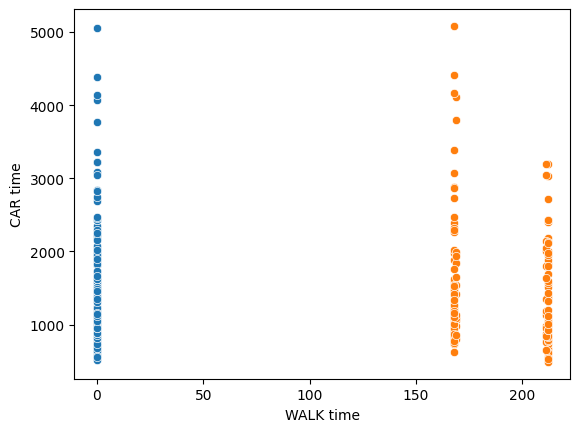

In [6]:
df_compare["CAR_car"] = 0.0
df_compare["WALK_car"] = 0.0
for i, (durations, modes) in enumerate(zip(df_compare["transport_durations_car"], df_compare["transport_modes_car"])):
    for d, m in zip(durations, modes):
        m_mod = f"{m}_car"
        df_compare.loc[i, m_mod] = d
df_compare["CAR_carPark"] = 0.0
df_compare["WALK_carPark"] = 0.0
for i, (durations, modes) in enumerate(zip(df_compare["transport_durations_carPark"], df_compare["transport_modes_carPark"])):
    for d, m in zip(durations, modes):
        m_mod = f"{m}_carPark"
        df_compare.loc[i, m_mod] = d

# Scatterplot
p = sns.scatterplot(data=df_compare, y="CAR_car", x="WALK_car")
p = sns.scatterplot(data=df_compare, y="CAR_carPark", x="WALK_carPark")
p = plt.xlabel("WALK time")
p = plt.ylabel("CAR time")


In [7]:
df_car["waiting_time"] = df_car["duration_seconds"] - df_car["transport_durations"].apply(lambda x: sum(x))
print(df_car["waiting_time"].describe())

df_car_park["waiting_time"] = df_car_park["duration_seconds"] - df_car_park["transport_durations"].apply(lambda x: sum(x))
print(df_car_park["waiting_time"].describe())

df_car_park

count    152.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: waiting_time, dtype: float64
count    152.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: waiting_time, dtype: float64


,row_index,origin_lat,origin_lon,from,dest_lat,dest_lon,to,origin_lat_tmp,origin_lon_tmp,dest_lat_tmp,...,walk_time_seconds,number_of_legs,transport_modes,transport_mode_sequences,transport_durations,transport_percentages,number_of_transit_transfers,start_time,end_time,waiting_time
0,0,44.109145,10.939834,8037029,44.497006,11.344162,0,44.109145,10.939834,44.497006,...,168,2,"[CAR, WALK]",[],"[5083.0, 168.0]","[96.8, 3.2]",0,2025-06-10T07:00:00+02:00,2025-06-10T08:27:31+02:00,0.0
1,1,44.149540,10.931946,8037049,44.497006,11.344162,0,44.149540,10.931946,44.497006,...,168,2,"[CAR, WALK]",[],"[4412.0, 168.0]","[96.33, 3.67]",0,2025-06-10T07:00:00+02:00,2025-06-10T08:16:20+02:00,0.0
2,2,44.150671,11.183166,8037022,44.497006,11.344162,0,44.150671,11.183166,44.497006,...,168,2,"[CAR, WALK]",[],"[2383.0, 168.0]","[93.41, 6.59]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:42:31+02:00,0.0
3,3,44.152876,11.095953,8037010,44.497006,11.344162,0,44.152876,11.095953,44.497006,...,168,2,"[CAR, WALK]",[],"[3389.0, 168.0]","[95.28, 4.72]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:59:17+02:00,0.0
4,4,44.159536,11.022521,8037015,44.497006,11.344162,0,44.159536,11.022521,44.497006,...,169,2,"[CAR, WALK]",[],"[4107.0, 169.0]","[96.05, 3.95]",0,2025-06-10T07:00:00+02:00,2025-06-10T08:11:16+02:00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,147,44.687466,11.509805,8037035,44.497006,11.344162,0,44.687466,11.509805,44.497006,...,212,2,"[CAR, WALK]",[],"[1434.0, 212.0]","[87.12, 12.88]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:27:26+02:00,0.0
148,148,44.710507,11.404958,8037055,44.497006,11.344162,0,44.710507,11.404958,44.497006,...,211,2,"[CAR, WALK]",[],"[1634.0, 211.0]","[88.56, 11.44]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:30:45+02:00,0.0
149,149,44.733801,11.325515,8037048,44.497006,11.344162,0,44.733801,11.325515,44.497006,...,168,2,"[CAR, WALK]",[],"[2286.0, 168.0]","[93.15, 6.85]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:40:54+02:00,0.0
150,150,44.746971,11.429432,8037028,44.497006,11.344162,0,44.746971,11.429432,44.497006,...,212,2,"[CAR, WALK]",[],"[1981.0, 212.0]","[90.33, 9.67]",0,2025-06-10T07:00:00+02:00,2025-06-10T07:36:33+02:00,0.0


# TRANSIT_CAR_PARK

In [8]:
# Check, when car_park and transit, the % of times that transit is choosen -> the bus is never chosen!
all_modes = set([])
for modes in df_car_trans["transport_modes"]:
    for m in modes:
        if m not in all_modes:
            all_modes.add(m)
all_modes

{'CAR', 'WALK'}

# TRANSIT

In [9]:
# Check transit only
print("N. elements:", df_trans.shape[0])
print("N. elements non successful:", df_trans[df_trans["status"]!="success"].shape[0])
df_trans_nona = df_trans[(df_trans["status"]=="success") & ~(df_trans["row_index"].isna())]
print("N. new elements:", df_trans_nona.shape[0])

N. elements: 152
N. elements non successful: 11
N. new elements: 141


In [10]:
df_trans_nona[["transport_durations"]].apply(lambda x: len(x))

transport_durations    141
dtype: int64

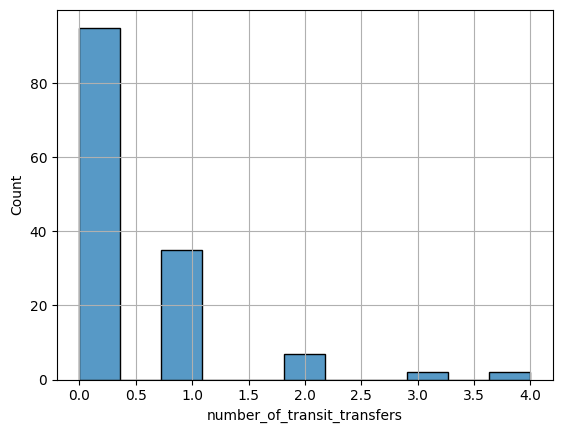

In [11]:
sns.histplot(data=df_trans_nona, x="number_of_transit_transfers")
plt.grid()

<Axes: xlabel='number_of_transit_transfers', ylabel='duration_seconds'>

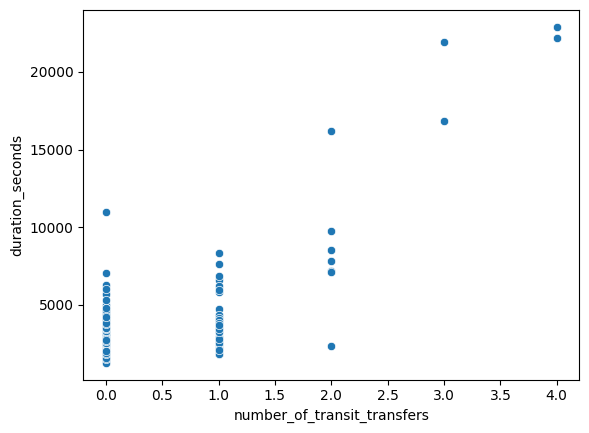

In [12]:
sns.scatterplot(data=df_trans_nona, x="number_of_transit_transfers", y="duration_seconds")

<Axes: >

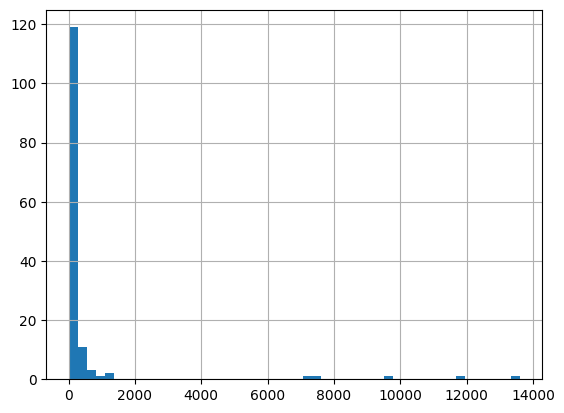

In [13]:
df_trans_nona["waiting_time"] = df_trans_nona["duration_seconds"] - df_trans_nona["transport_durations"].apply(lambda x: sum(x))
df_trans_nona["waiting_time"].hist(bins=50)

<Axes: >

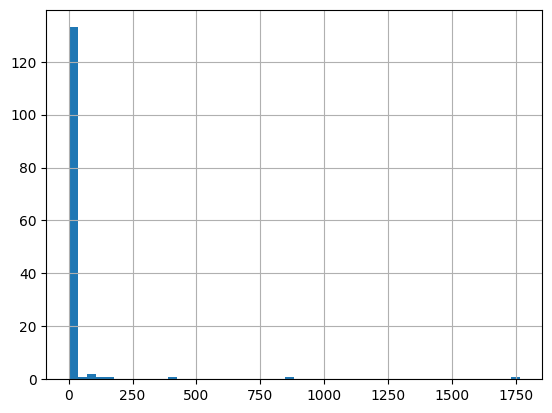

In [14]:
df_trans_nona["change_time"] = 0
for i, row in df_trans_nona.iterrows():
    t = 0
    for a1,a2 in zip( row["transport_durations"][1:-1], row["transport_modes"][1:-1]):
        if a2 == "WALK":
            t = t + a1
    if t > 0:
        df_trans_nona.at[i, "change_time"] = t
df_trans_nona["change_time"].hist(bins=50)

<Axes: >

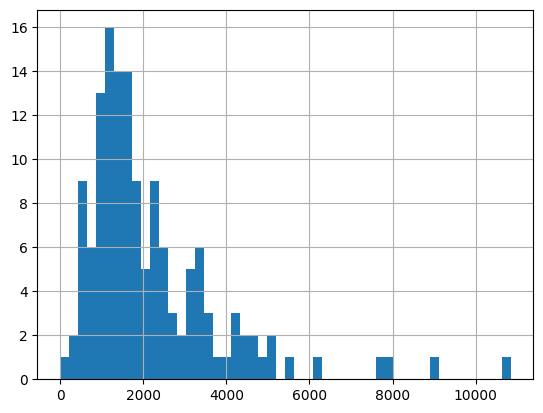

In [15]:
df_trans_nona["onboard_time"] = 0.0
for i, row in df_trans_nona.iterrows():
    t = 0
    for a1,a2 in zip( row["transport_durations"], row["transport_modes"]):
        if a2 == "BUS":
            t = t + a1
    if t > 0:
        df_trans_nona.at[i, "onboard_time"] = t
df_trans_nona["onboard_time"].hist(bins=50)

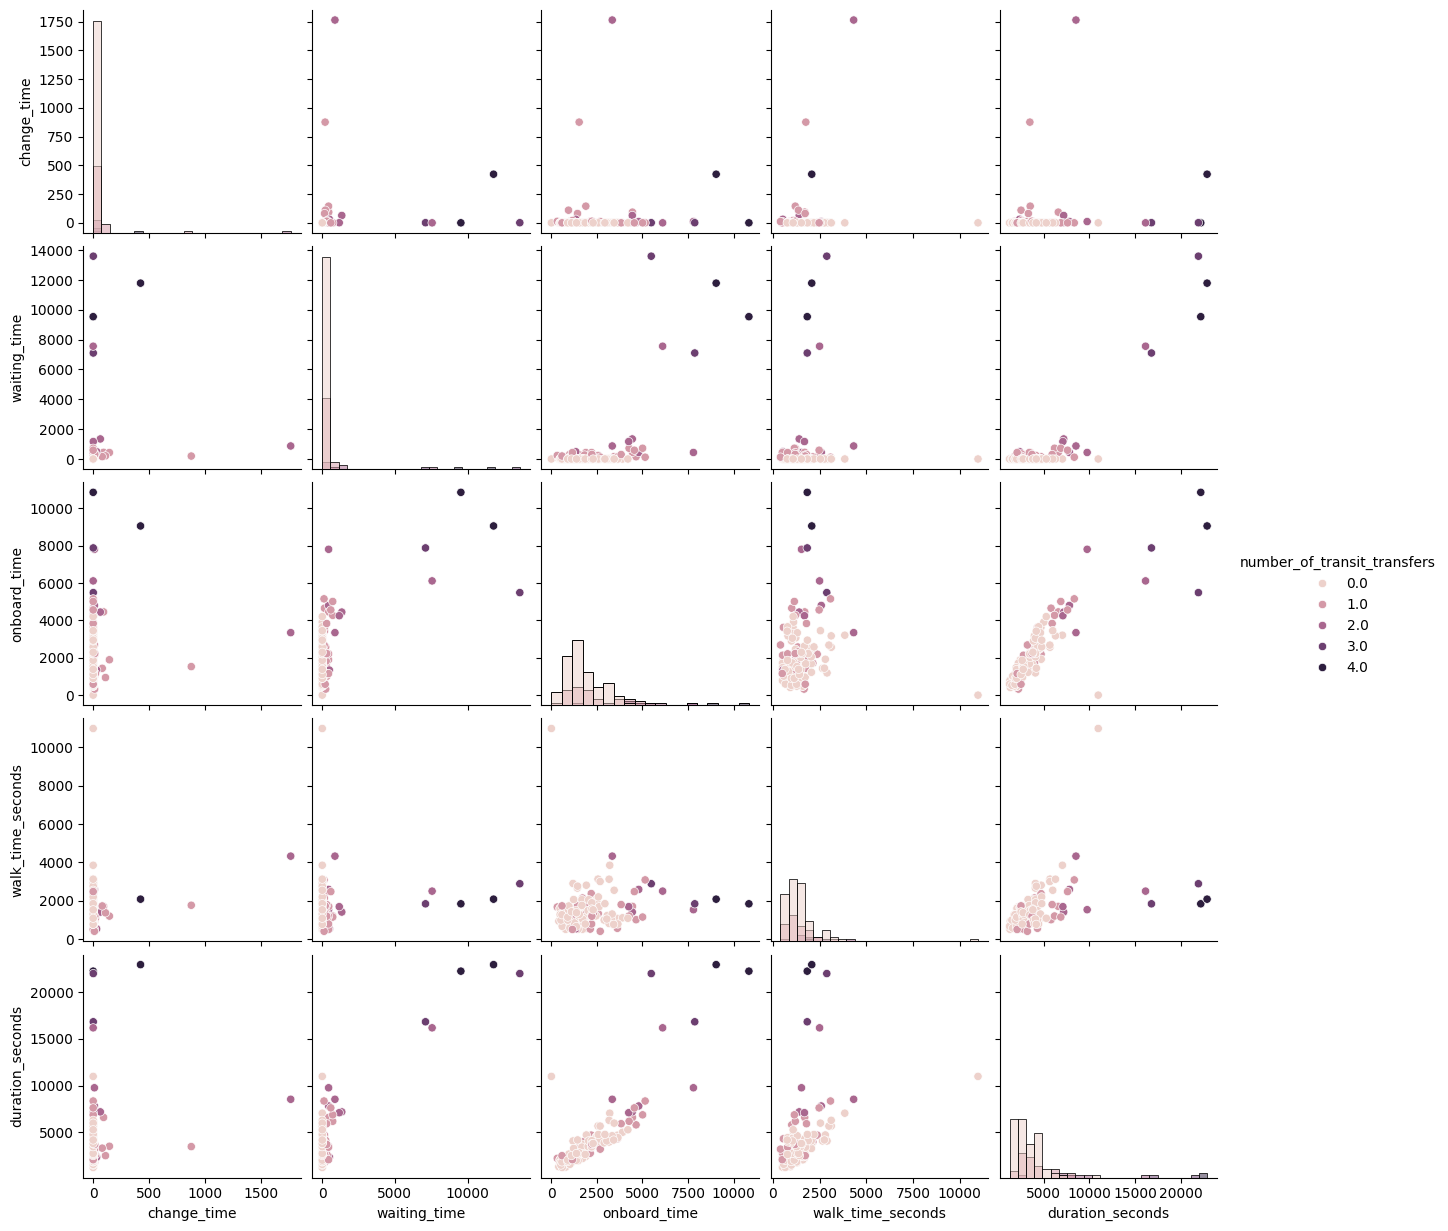

In [16]:
sns.pairplot(
    data=df_trans_nona[["change_time", "waiting_time", "onboard_time", "walk_time_seconds", "duration_seconds", "number_of_transit_transfers"]],
    hue="number_of_transit_transfers",
    diag_kind="hist"
)

In [17]:
df_trans_nona[["change_time", "waiting_time", "onboard_time", "walk_time_seconds", "duration_seconds"]].isna().apply(sum, axis=0)

change_time          0
waiting_time         0
onboard_time         0
walk_time_seconds    0
duration_seconds     0
dtype: int64

# CAR AND TRANSIT

In [18]:
# Check diff between car and transit
df_compare = pd.merge(
    df_car_park,
    df_trans,
    suffixes=["_carPark", "_trans"],
    how="outer",
    on=['row_index', 'origin_lat', 'origin_lon', 'from', 'dest_lat', 'dest_lon','to']
)

print("N. NAs in trans:", int(df_compare["duration_seconds_trans"].isna().sum()))
print("N. NAs in carPark:", int(df_compare["duration_seconds_carPark"].isna().sum()))

print("N. success in trans:", sum(df_compare["status_trans"]=="success"))
print("N. success in carPark:", sum(df_compare["status_carPark"]=="success"))

df_compare = df_compare[df_compare["status_trans"]=="success"]
df_compare.head()

N. NAs in trans: 11
N. NAs in carPark: 0
N. success in trans: 141
N. success in carPark: 152


,row_index,origin_lat,origin_lon,from,dest_lat,dest_lon,to,origin_lat_tmp_carPark,origin_lon_tmp_carPark,dest_lat_tmp_carPark,...,walk_time_seconds_trans,number_of_legs_trans,transport_modes_trans,transport_mode_sequences_trans,transport_durations_trans,transport_percentages_trans,number_of_transit_transfers_trans,start_time_trans,end_time_trans,transport_sequence
0,0,44.109145,10.939834,8037029,44.497006,11.344162,0,44.109145,10.939834,44.497006,...,1834.0,7.0,"[WALK, BUS, BUS, BUS, BUS, BUS, WALK]",[],"[1323.0, 2385.0, 2100.0, 1860.0, 2640.0, 1860....","[10.43, 18.81, 16.56, 14.67, 20.82, 14.67, 4.03]",4.0,2025-06-10T07:53:12+02:00,2025-06-10T14:03:31+02:00,None
2,2,44.150671,11.183166,8037022,44.497006,11.344162,0,44.150671,11.183166,44.497006,...,1527.0,6.0,"[WALK, BUS, BUS, WALK, BUS, WALK]",[],"[1311.0, 4287.0, 3169.0, 11.0, 343.0, 205.0]","[14.06, 45.97, 33.98, 0.12, 3.68, 2.2]",2.0,2025-06-10T07:06:42+02:00,2025-06-10T09:49:25+02:00,None
3,3,44.152876,11.095953,8037010,44.497006,11.344162,0,44.152876,11.095953,44.497006,...,1834.0,7.0,"[WALK, BUS, BUS, WALK, BUS, BUS, WALK]",[],"[1058.0, 1009.0, 1360.0, 1.0, 2334.0, 3169.0, ...","[10.9, 10.4, 14.01, 0.01, 24.05, 32.65, 7.98]",3.0,2025-06-10T07:40:33+02:00,2025-06-10T12:20:44+02:00,None
4,4,44.159536,11.022521,8037015,44.497006,11.344162,0,44.159536,11.022521,44.497006,...,2077.0,8.0,"[WALK, BUS, WALK, BUS, BUS, BUS, BUS, WALK]",[],"[1143.0, 1133.0, 423.0, 1554.0, 1860.0, 2640.0...","[10.28, 10.19, 3.8, 13.97, 16.72, 23.73, 16.72...",4.0,2025-06-10T07:41:38+02:00,2025-06-10T14:03:31+02:00,None
6,6,44.217239,11.321332,8037040,44.497006,11.344162,0,44.217239,11.321332,44.497006,...,1005.0,4.0,"[WALK, BUS, BUS, WALK]",[],"[347.0, 4175.0, 475.0, 658.0]","[6.14, 73.83, 8.4, 11.64]",1.0,2025-06-10T07:24:13+02:00,2025-06-10T09:00:58+02:00,None


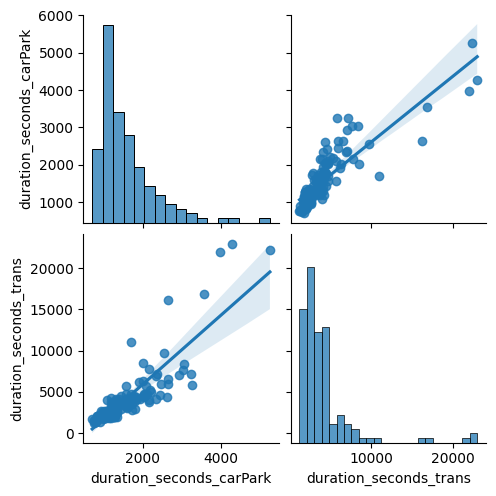

In [19]:
sns.pairplot(
    data=df_compare[["duration_seconds_carPark", "duration_seconds_trans"]],
    kind="reg"
)

# Not allBologna, but restrictedAv

In [22]:
zoi: str = "restrictedAv"  ## Choose between "allBologna" and "restrictedAv"
method: str = "simplified" ## Choose between "simplified" and "extended"
version: str = "20250926"

In [24]:
df_car_trans_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_TRANSIT_v{version}")
df_car_trans = df_car_trans_di.as_df()

df_car_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_v{version}")
df_car = df_car_di.as_df()

df_car_park_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_v{version}")
df_car_park = df_car_park_di.as_df()

df_trans_di = project.get_dataitem(f"otp_results_{method}_{zoi}_TRANSIT_v{version}")
df_trans = df_trans_di.as_df()

print(df_car.columns)

Index(['row_index', 'origin_lat', 'origin_lon', 'from', 'dest_lat', 'dest_lon',
       'to', 'origin_lat_tmp', 'origin_lon_tmp', 'dest_lat_tmp',
       'dest_lon_tmp', 'n_iter', 'status', 'duration_seconds',
       'walk_time_seconds', 'number_of_legs', 'transport_modes',
       'transport_mode_sequences', 'transport_sequence', 'transport_durations',
       'transport_percentages', 'number_of_transit_transfers', 'start_time',
       'end_time'],
      dtype='object')


In [28]:
df_car_park["status"].value_counts()

status
success           151
no_itineraries      1
Name: count, dtype: int64

In [35]:
df_car[df_car["status"]=="success"]#[["delat_tmp", "dest_lon_tmp"]]

,row_index,origin_lat,origin_lon,from,dest_lat,dest_lon,to,origin_lat_tmp,origin_lon_tmp,dest_lat_tmp,...,walk_time_seconds,number_of_legs,transport_modes,transport_mode_sequences,transport_sequence,transport_durations,transport_percentages,number_of_transit_transfers,start_time,end_time
2,2,44.150671,11.183166,8037022,44.497006,11.344162,0,44.151570,11.185706,44.495208,...,0.0,1.0,[CAR],[],None,[2697.0],[100.0],0.0,2025-06-10T07:00:00+02:00,2025-06-10T07:44:57+02:00
9,9,44.272097,11.610780,8037007,44.497006,11.344162,0,44.271648,11.610145,44.494759,...,0.0,1.0,[CAR],[],None,[4221.0],[100.0],0.0,2025-06-10T07:00:00+02:00,2025-06-10T08:10:21+02:00
10,10,44.279534,11.016231,8037013,44.497006,11.344162,0,44.279983,11.014326,44.494759,...,0.0,1.0,[CAR],[],None,[3652.0],[100.0],0.0,2025-06-10T07:00:00+02:00,2025-06-10T08:00:52+02:00
11,11,44.282099,11.326648,8037034,44.497006,11.344162,0,44.282099,11.321568,44.495208,...,0.0,1.0,[CAR],[],None,[2171.0],[100.0],0.0,2025-06-10T07:00:00+02:00,2025-06-10T07:36:11+02:00
38,38,44.444654,11.661898,8037016,44.497006,11.344162,0,44.444654,11.661898,44.495208,...,0.0,1.0,[CAR],[],None,[2832.0],[100.0],0.0,2025-06-10T07:00:00+02:00,2025-06-10T07:47:12+02:00
39,39,44.449825,11.382407,242,44.497006,11.344162,0,44.449825,11.382407,44.495208,...,0.0,1.0,[CAR],[],None,[1654.0],[100.0],0.0,2025-06-10T07:00:00+02:00,2025-06-10T07:27:34+02:00
54,54,44.473418,11.275382,141,44.497006,11.344162,0,44.473418,11.276652,44.495208,...,0.0,1.0,[CAR],[],None,[2236.0],[100.0],0.0,2025-06-10T07:00:00+02:00,2025-06-10T07:37:16+02:00
55,55,44.473427,11.254476,140,44.497006,11.344162,0,44.472978,11.252571,44.494759,...,0.0,1.0,[CAR],[],None,[2413.0],[100.0],0.0,2025-06-10T07:00:00+02:00,2025-06-10T07:40:13+02:00
57,57,44.476252,11.426511,243,44.497006,11.344162,0,44.474903,11.429686,44.494759,...,0.0,1.0,[CAR],[],None,[1918.0],[100.0],0.0,2025-06-10T07:00:00+02:00,2025-06-10T07:31:58+02:00
60,60,44.478663,11.404092,62,44.497006,11.344162,0,44.480012,11.405997,44.492961,...,0.0,1.0,[CAR],[],None,[1843.0],[100.0],0.0,2025-06-10T07:00:00+02:00,2025-06-10T07:30:43+02:00
